# TP/FP Similarity Distribution Fitting
**File:** `tp_fp_similarity_distributions.ipynb` (renamed from `tp_fp_distributions.ipynb`)

## Purpose
Fits statistical distributions (Beta, KDE, logistic) to TP and FP entropy similarity scores from labeled confirmed spectra. Establishes the empirical LR = f_TP(sim) / f_FP(sim) used in the MS2 channel.

## What is done
- Loads confirmed hits from labeled train data
- Fits Beta distributions on TP/FP similarity scores in unbiased range [0.3, 0.8]
- Fits KDE (bandwidth=0.05) for smooth LR curve
- Compares Beta extrapolation vs KDE in high-similarity region
- Identifies annotation bias spike near sim=1.0 (TP artificially inflated)
- Evaluates logistic regression as alternative to KDE

## Status
SUPERSEDED — TP/FP fitting is now done inline in `proposal_mvp.ipynb` (cells 8-10) and `channel_ceiling.ipynb` (Step 3). Retained as reference for distribution fitting methodology and the annotation bias finding.

## Key finding
Beta fit on [0.3, 0.8] avoids annotation bias. KDE LR peaks at ~83 for sim=1.0. FP distribution is bimodal: low-sim wrong candidates + high-sim structural isomers.


# TP/FP Distribution Fitting from Labeled Train/TN Data

**Goal:** Replace the softmax heuristic in `LR_MS2` with a principled likelihood ratio
fitted from real labeled examples:
- `hilic_train.csv` — true positives (confirmed correct annotations)
- `hilic_tn.csv`   — true negatives (rejected annotations, despite high spectral scores)

Both are HILIC Orbitrap (positive + negative mode).  
The main scoring pipeline uses HILIC Orbitrap **negative** mode, so we fit on all data
but evaluate the negative-mode subset separately.

**Pipeline:**
1. EDA — visualise TP vs FP score distributions  
2. Distribution fitting — Beta and KDE fits  
3. `LR_MS2(s)` = P(s | TP) / P(s | FP) as a calibrated likelihood ratio  
4. Binary annotation quality classifier (logistic + random forest)  
5. Apply to existing `assertions.csv` — compare with current softmax approach

In [1]:
import os, warnings
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import beta as beta_dist
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

ROOT     = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(ROOT, 'data')
OUT_DIR  = os.path.join(ROOT, 'out_tp_fp')
os.makedirs(OUT_DIR, exist_ok=True)
print('Output dir:', OUT_DIR)

Output dir: /Users/ellayoung/Desktop/metabolo_confi_score/out_tp_fp


## 1. Load & Clean

In [2]:
train_raw = pd.read_csv(os.path.join(DATA_DIR, 'hilic_train.csv'))
tn_raw    = pd.read_csv(os.path.join(DATA_DIR, 'hilic_tn.csv'))

# ── True Positives: confirmed correct annotations ──────────────────────────
# Exclude:
#   yy_  = curator flagged as uncertain
#   1_   = internal standards (not metabolites)
def name_flag(s):
    s = str(s).lower().strip()
    if s.startswith('yy_'): return 'yy'
    if s.startswith('zz'): return 'zz'
    if s.startswith('1_'): return 'istd'
    return 'clean'

train_raw['flag'] = train_raw['user_annotation-name'].apply(name_flag)
tn_raw['flag']    = tn_raw['user_annotation-name'].apply(name_flag)

tp = train_raw[train_raw['flag'] == 'clean'].copy()
fp = tn_raw[tn_raw['flag'] == 'zz'].copy()       # all zz_ entries are explicit rejects

tp['label'] = 1
fp['label'] = 0

tp['mode'] = tp['method'].str.extract(r'(positive|negative)')[0]
fp['mode'] = fp['method'].str.extract(r'(positive|negative)')[0]

print(f'TP (clean train): {len(tp):,}  |  pos={( tp["mode"]=="positive").sum()}, neg={(tp["mode"]=="negative").sum()}')
print(f'FP (zz tn):       {len(fp):,}  |  pos={(fp["mode"]=="positive").sum()}, neg={(fp["mode"]=="negative").sum()}')
print()
print(f'TP score: mean={tp["library_search-identity_score"].mean():.3f}, '
      f'median={tp["library_search-identity_score"].median():.3f}')
print(f'FP score: mean={fp["library_search-identity_score"].mean():.3f}, '
      f'median={fp["library_search-identity_score"].median():.3f}')

TP (clean train): 2,673  |  pos=1718, neg=955
FP (zz tn):       341  |  pos=275, neg=66

TP score: mean=0.818, median=0.841
FP score: mean=0.837, median=0.828


## 2. EDA — Score Distributions

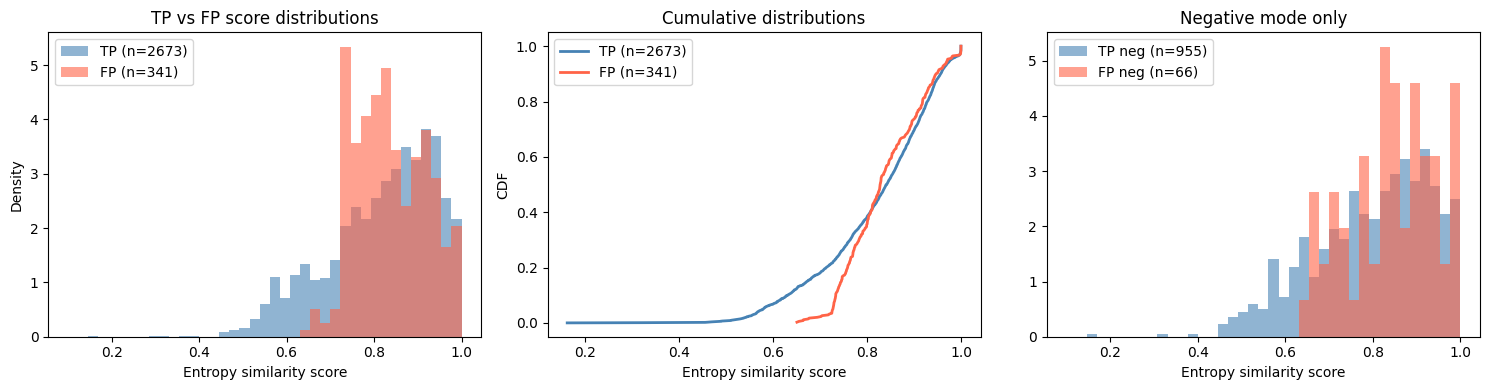

KS test (all modes):  D=0.183, p=2.34e-09
KS test (neg mode):   D=0.165, p=6.01e-02


In [3]:
tp_scores = tp['library_search-identity_score'].values
fp_scores = fp['library_search-identity_score'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram overlay
bins = np.linspace(0.1, 1.0, 40)
axes[0].hist(tp_scores, bins=bins, alpha=0.6, color='steelblue', density=True, label=f'TP (n={len(tp_scores)})')
axes[0].hist(fp_scores, bins=bins, alpha=0.6, color='tomato',    density=True, label=f'FP (n={len(fp_scores)})')
axes[0].set_xlabel('Entropy similarity score')
axes[0].set_ylabel('Density')
axes[0].set_title('TP vs FP score distributions')
axes[0].legend()

# Cumulative (manual ECDF — compatible with older matplotlib)
def plot_ecdf(ax, scores, label, color):
    xs = np.sort(scores)
    ys = np.arange(1, len(xs)+1) / len(xs)
    ax.plot(xs, ys, color=color, lw=2, label=label)

plot_ecdf(axes[1], tp_scores, f'TP (n={len(tp_scores)})', 'steelblue')
plot_ecdf(axes[1], fp_scores, f'FP (n={len(fp_scores)})', 'tomato')
axes[1].set_xlabel('Entropy similarity score')
axes[1].set_ylabel('CDF')
axes[1].set_title('Cumulative distributions')
axes[1].legend()

# Negative mode only
tp_neg = tp[tp['mode']=='negative']['library_search-identity_score'].values
fp_neg = fp[fp['mode']=='negative']['library_search-identity_score'].values
axes[2].hist(tp_neg, bins=bins, alpha=0.6, color='steelblue', density=True, label=f'TP neg (n={len(tp_neg)})')
axes[2].hist(fp_neg, bins=bins, alpha=0.6, color='tomato',    density=True, label=f'FP neg (n={len(fp_neg)})')
axes[2].set_xlabel('Entropy similarity score')
axes[2].set_title('Negative mode only')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'score_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

# KS test
ks_stat, ks_p = stats.ks_2samp(tp_scores, fp_scores)
print(f'KS test (all modes):  D={ks_stat:.3f}, p={ks_p:.2e}')
if len(fp_neg) > 5:
    ks2, p2 = stats.ks_2samp(tp_neg, fp_neg)
    print(f'KS test (neg mode):   D={ks2:.3f}, p={p2:.2e}')

## 3. Distribution Fitting

TP Beta fit: a=5.142, b=1.111  (mode=0.974 when a,b>1)
FP Beta fit: a=7.456, b=1.394  (mean=0.842)



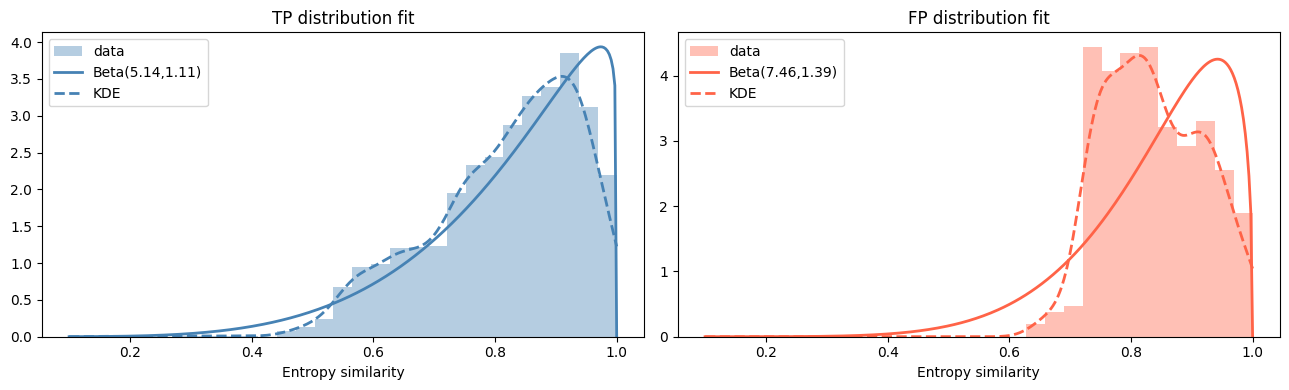

In [4]:
from scipy.stats import beta as beta_dist
from scipy.stats import gaussian_kde

# ── Beta distribution fit ──────────────────────────────────────────────────
# Beta(a, b) is natural for [0,1]-bounded scores.
# Clip away exact 0/1 to avoid log(0) in MLE.
def fit_beta(scores):
    s = np.clip(scores, 1e-6, 1 - 1e-6)
    a, b, loc, scale = beta_dist.fit(s, floc=0, fscale=1)
    return a, b

tp_a, tp_b = fit_beta(tp_scores)
fp_a, fp_b = fit_beta(fp_scores)

print(f'TP Beta fit: a={tp_a:.3f}, b={tp_b:.3f}  '
      f'(mode={(tp_a-1)/(tp_a+tp_b-2):.3f} when a,b>1)')
print(f'FP Beta fit: a={fp_a:.3f}, b={fp_b:.3f}  '
      f'(mean={fp_a/(fp_a+fp_b):.3f})')
print()

# ── KDE fit (non-parametric alternative) ──────────────────────────────────
tp_kde = gaussian_kde(np.clip(tp_scores, 1e-4, 1 - 1e-4), bw_method='silverman')
fp_kde = gaussian_kde(np.clip(fp_scores, 1e-4, 1 - 1e-4), bw_method='silverman')

# ── Visualise fits ────────────────────────────────────────────────────────
s_grid = np.linspace(0.1, 1.0, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, label, scores, a, b, kde, color in [
    (axes[0], 'TP', tp_scores, tp_a, tp_b, tp_kde, 'steelblue'),
    (axes[1], 'FP', fp_scores, fp_a, fp_b, fp_kde, 'tomato'),
]:
    bins = np.linspace(0.1, 1.0, 30)
    ax.hist(scores, bins=bins, density=True, alpha=0.4, color=color, label='data')
    ax.plot(s_grid, beta_dist.pdf(s_grid, a, b), color=color, lw=2, label=f'Beta({a:.2f},{b:.2f})')
    ax.plot(s_grid, kde(s_grid),                  color=color, lw=2, ls='--', label='KDE')
    ax.set_title(f'{label} distribution fit')
    ax.set_xlabel('Entropy similarity')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'distribution_fits.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. LR_MS2 — Likelihood Ratio from Fitted Distributions

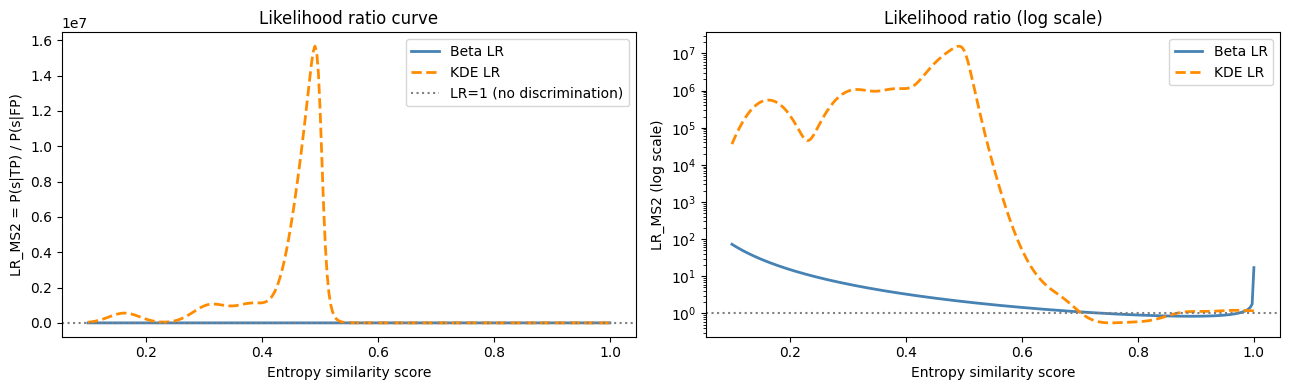

  s=0.30  LR_beta=6.15  LR_kde=959919.12
  s=0.50  LR_beta=2.08  LR_kde=12230594.57
  s=0.70  LR_beta=1.10  LR_kde=1.08
  s=0.80  LR_beta=0.91  LR_kde=0.60
  s=0.90  LR_beta=0.84  LR_kde=1.13
  s=0.95  LR_beta=0.90  LR_kde=1.19
  s=0.99  LR_beta=1.29  LR_kde=1.20


In [5]:
# ── LR_MS2(s) = P(s | TP) / P(s | FP) ───────────────────────────────────
# Values > 1: score favours TP.  Values < 1: score favours FP.

EPSILON_PDF = 1e-8   # floor to avoid division by zero

def lr_ms2_beta(s):
    """LR using fitted Beta distributions. Always returns ndarray."""
    s = np.atleast_1d(np.clip(np.asarray(s, dtype=float), 1e-6, 1 - 1e-6))
    p_tp = beta_dist.pdf(s, tp_a, tp_b) + EPSILON_PDF
    p_fp = beta_dist.pdf(s, fp_a, fp_b) + EPSILON_PDF
    return p_tp / p_fp

def lr_ms2_kde(s):
    """LR using KDE (non-parametric). Always returns ndarray."""
    s = np.atleast_1d(np.clip(np.asarray(s, dtype=float), 1e-4, 1 - 1e-4))
    p_tp = tp_kde(s) + EPSILON_PDF
    p_fp = fp_kde(s) + EPSILON_PDF
    return p_tp / p_fp

# ── Plot LR curve ─────────────────────────────────────────────────────────
s_grid = np.linspace(0.1, 1.0, 300)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

lr_beta_vals = lr_ms2_beta(s_grid)
lr_kde_vals  = lr_ms2_kde(s_grid)

axes[0].plot(s_grid, lr_beta_vals, color='steelblue', lw=2, label='Beta LR')
axes[0].plot(s_grid, lr_kde_vals,  color='darkorange', lw=2, ls='--', label='KDE LR')
axes[0].axhline(1.0, color='grey', ls=':', label='LR=1 (no discrimination)')
axes[0].set_xlabel('Entropy similarity score')
axes[0].set_ylabel('LR_MS2 = P(s|TP) / P(s|FP)')
axes[0].set_title('Likelihood ratio curve')
axes[0].legend()

# Log scale
axes[1].semilogy(s_grid, lr_beta_vals, color='steelblue', lw=2, label='Beta LR')
axes[1].semilogy(s_grid, lr_kde_vals,  color='darkorange', lw=2, ls='--', label='KDE LR')
axes[1].axhline(1.0, color='grey', ls=':')
axes[1].set_xlabel('Entropy similarity score')
axes[1].set_ylabel('LR_MS2 (log scale)')
axes[1].set_title('Likelihood ratio (log scale)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'lr_ms2_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

# Key reference points
for s_val in [0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]:
    print(f'  s={s_val:.2f}  LR_beta={lr_ms2_beta(s_val)[0]:.2f}  '
          f'LR_kde={lr_ms2_kde(s_val)[0]:.2f}')

## 5. Binary Annotation Quality Classifier

In [6]:
# ── Feature engineering ───────────────────────────────────────────────────
# Use features available for any spectrum without MassWiki re-fetching:
#   - library_search-identity_score (entropy sim)
#   - ms1_inte (log-transformed, proxy for signal quality)
#   - charge
#   - adduct family (simplified: [M+H]+, [M-H]-, other)

def simplify_adduct(a):
    a = str(a).strip()
    if a in ('[M+H]+', 'M+H'):     return 'MH'
    if a in ('[M-H]-', 'M-H'):     return 'MH_neg'
    if '[M+H-' in a:               return 'MH_loss'
    if '[M-H-' in a:               return 'MH_neg_loss'
    return 'other'

def make_features(df):
    feat = pd.DataFrame()
    feat['score']      = pd.to_numeric(df['library_search-identity_score'], errors='coerce')
    feat['log_ms1']    = np.log1p(pd.to_numeric(df['ms1_inte'], errors='coerce').fillna(0))
    feat['charge']     = pd.to_numeric(df['charge'], errors='coerce').fillna(1)
    adduct_simple      = df['adduct'].apply(simplify_adduct)
    for cat in ['MH', 'MH_neg', 'MH_loss', 'MH_neg_loss', 'other']:
        feat[f'adduct_{cat}'] = (adduct_simple == cat).astype(int)
    feat['is_neg_mode'] = df['method'].str.contains('negative').astype(int)
    return feat.fillna(0)

all_data = pd.concat([tp, fp], ignore_index=True)
X = make_features(all_data)
y = all_data['label'].values

print(f'Feature matrix: {X.shape}, class balance: TP={y.sum()}, FP={(1-y).sum()}')
print('Features:', X.columns.tolist())

Feature matrix: (3014, 9), class balance: TP=2673, FP=341
Features: ['score', 'log_ms1', 'charge', 'adduct_MH', 'adduct_MH_neg', 'adduct_MH_loss', 'adduct_MH_neg_loss', 'adduct_other', 'is_neg_mode']


In [7]:
# ── Cross-validated ROC-AUC ──────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_clf  = LogisticRegression(max_iter=500, class_weight='balanced')
rf_clf  = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

lr_auc = cross_val_score(lr_clf, X, y, cv=cv, scoring='roc_auc')
rf_auc = cross_val_score(rf_clf, X, y, cv=cv, scoring='roc_auc')

# Score-only baseline (1 feature)
score_only_auc = cross_val_score(
    LogisticRegression(max_iter=200), X[['score']], y, cv=cv, scoring='roc_auc'
)

print('5-fold CV ROC-AUC:')
print(f'  Score-only logistic: {score_only_auc.mean():.4f} ± {score_only_auc.std():.4f}')
print(f'  Logistic regression: {lr_auc.mean():.4f} ± {lr_auc.std():.4f}')
print(f'  Random Forest:       {rf_auc.mean():.4f} ± {rf_auc.std():.4f}')

5-fold CV ROC-AUC:
  Score-only logistic: 0.5136 ± 0.0313
  Logistic regression: 0.6752 ± 0.0587
  Random Forest:       0.6949 ± 0.0474


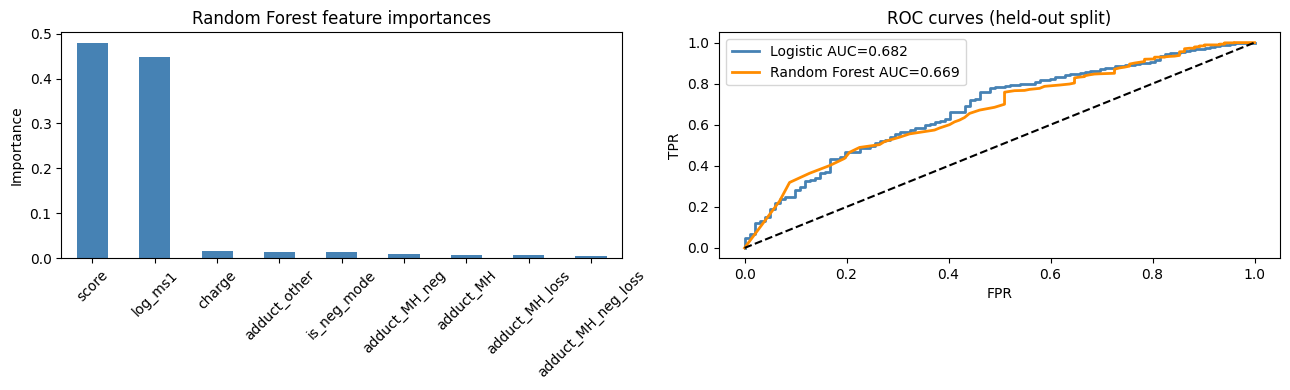

Feature importances:
score                 0.4789
log_ms1               0.4481
charge                0.0161
adduct_other          0.0142
is_neg_mode           0.0139
adduct_MH_neg         0.0084
adduct_MH             0.0078
adduct_MH_loss        0.0077
adduct_MH_neg_loss    0.0048


In [8]:
# ── Fit final RF on all data, inspect feature importances ────────────────
rf_clf.fit(X, y)

importances = pd.Series(rf_clf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

importances.plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest feature importances')
axes[0].set_ylabel('Importance')
axes[0].tick_params(axis='x', rotation=45)

# ROC curves (single split for illustration)
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
for clf, name, color in [(lr_clf, 'Logistic', 'steelblue'), (rf_clf, 'Random Forest', 'darkorange')]:
    clf.fit(X_tr, y_tr)
    probs = clf.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, probs)
    auc = roc_auc_score(y_te, probs)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{name} AUC={auc:.3f}')

axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC curves (held-out split)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'classifier.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Feature importances:')
print(importances.round(4).to_string())

## 6. Apply to Main Pipeline — Compare LR_MS2 Approaches

In [9]:
# Load existing assertions from the Bayesian pipeline
ass_path = os.path.join(ROOT, 'out_proposal', 'assertions.csv')
ass = pd.read_csv(ass_path)

print(f'assertions.csv: {len(ass):,} rows, {ass["wiki_id"].nunique():,} spectra')
print(f'Confirmed: {ass["confirmed"].sum():,}  |  Correct labels: {ass["correct"].sum():,}')
print()

# Compute new LR_MS2 using Beta fit
ass['LR_ms2_beta'] = lr_ms2_beta(ass['entropy_similarity'].values)
ass['LR_ms2_kde']  = lr_ms2_kde(ass['entropy_similarity'].values)

print('LR_ms2 comparison (confirmed hits only):')
conf = ass[ass['confirmed']]
print(conf[['LR_ms2', 'LR_ms2_beta', 'LR_ms2_kde']].describe().round(3))

assertions.csv: 21,061 rows, 2,752 spectra
Confirmed: 6,366  |  Correct labels: 2,762



LR_ms2 comparison (confirmed hits only):
         LR_ms2  LR_ms2_beta    LR_ms2_kde
count  6366.000     6366.000  6.366000e+03
mean      1.000       43.397  4.789531e+05
std       0.786       88.589  1.785120e+06
min       0.011        0.839  5.570000e-01
25%       0.556        0.957  1.107000e+00
50%       0.956        2.535  5.035700e+01
75%       1.121       28.355  2.358770e+05
max      10.277      382.500  1.567001e+07


In [10]:
from scipy.special import softmax

# ── Recompute posteriors using Beta LR_MS2 ───────────────────────────────
# Keep all other channels (LR_ms1, prior) unchanged from the original.
# Only replace LR_ms2 with the Beta-fitted version.

results = []
for wid, grp in ass[ass['confirmed']].groupby('wiki_id'):
    # Raw scores from each approach
    grp = grp.copy()

    # --- original posterior (already in assertions.csv) ---
    orig_top    = grp.loc[grp['post'].idxmax()]
    orig_correct = bool(orig_top['correct'])

    # --- new posterior: replace LR_ms2 with Beta LR ---
    raw_beta = grp['LR_ms2_beta'] * grp['LR_ms1'] * grp['prior']
    p_novel  = grp['P_novel'].iloc[0]
    total    = raw_beta.sum() + p_novel
    post_beta = raw_beta / total
    beta_top  = grp.loc[post_beta.idxmax()]
    beta_correct = bool(beta_top['correct'])

    results.append({
        'wiki_id':       wid,
        'orig_correct':  orig_correct,
        'beta_correct':  beta_correct,
        'orig_post_top': float(orig_top['post']),
        'beta_post_top': float(post_beta.max()),
    })

res = pd.DataFrame(results)
n   = len(res)
print(f'Confirmed spectra evaluated: {n}')
print()
print(f'Original (softmax LR_MS2):   {res["orig_correct"].sum()}/{n} = {res["orig_correct"].mean()*100:.1f}%')
print(f'Beta LR_MS2 (same prior/MS1):{res["beta_correct"].sum()}/{n} = {res["beta_correct"].mean()*100:.1f}%')
print()

# Cases changed
improved = res[~res['orig_correct'] &  res['beta_correct']]
degraded = res[ res['orig_correct'] & ~res['beta_correct']]
print(f'Improved (orig wrong, beta right): {len(improved)}')
print(f'Degraded (orig right, beta wrong): {len(degraded)}')

Confirmed spectra evaluated: 585

Original (softmax LR_MS2):   427/585 = 73.0%
Beta LR_MS2 (same prior/MS1):132/585 = 22.6%

Improved (orig wrong, beta right): 15
Degraded (orig right, beta wrong): 310


Calibration — Original (softmax):
          accuracy    n
orig_bin               
<0.3         0.526  211
0.3-0.5      0.735  132
0.5-0.7      0.876   89
0.7-0.9      0.800   50
>0.9         0.981  103

Calibration — Beta LR_MS2:
          accuracy    n
beta_bin               
<0.3         0.119  226
0.3-0.5      0.134  127
0.5-0.7      0.167   78
0.7-0.9      0.151   53
>0.9         0.663  101


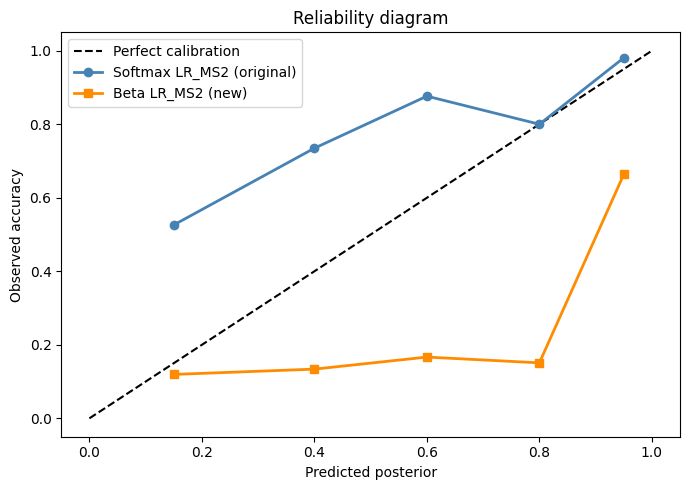

In [11]:
# ── Calibration comparison ───────────────────────────────────────────────
# Bin both posteriors and compare observed accuracy per bin

bins   = [0, 0.3, 0.5, 0.7, 0.9, 1.01]
labels = ['<0.3','0.3-0.5','0.5-0.7','0.7-0.9','>0.9']

res['orig_bin'] = pd.cut(res['orig_post_top'], bins=bins, labels=labels, right=False)
res['beta_bin'] = pd.cut(res['beta_post_top'], bins=bins, labels=labels, right=False)

orig_cal = res.groupby('orig_bin', observed=True)['orig_correct'].agg(['mean','count'])
beta_cal = res.groupby('beta_bin', observed=True)['beta_correct'].agg(['mean','count'])

orig_cal.columns = ['accuracy','n']
beta_cal.columns = ['accuracy','n']

print('Calibration — Original (softmax):')
print(orig_cal.round(3))
print()
print('Calibration — Beta LR_MS2:')
print(beta_cal.round(3))

# Plot reliability diagram
bin_centers = [0.15, 0.4, 0.6, 0.8, 0.95]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0,1],[0,1],'k--', label='Perfect calibration')

orig_acc = orig_cal['accuracy'].values
beta_acc = beta_cal['accuracy'].values

ax.plot(bin_centers[:len(orig_acc)], orig_acc, 'o-', color='steelblue',  lw=2, label='Softmax LR_MS2 (original)')
ax.plot(bin_centers[:len(beta_acc)], beta_acc, 's-', color='darkorange', lw=2, label='Beta LR_MS2 (new)')
ax.set_xlabel('Predicted posterior'); ax.set_ylabel('Observed accuracy')
ax.set_title('Reliability diagram')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'calibration_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary — Fitted Parameters

In [12]:
print('='*60)
print('FITTED PARAMETERS FOR LR_MS2')
print('='*60)
print(f'TP Beta distribution: a={tp_a:.4f}, b={tp_b:.4f}')
print(f'FP Beta distribution: a={fp_a:.4f}, b={fp_b:.4f}')
print()
print('LR_MS2(s) = Beta_pdf(s; tp_a, tp_b) / Beta_pdf(s; fp_a, fp_b)')
print()
print('Reference LR values:')
for s_val in [0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0]:
    lr = lr_ms2_beta(s_val)[0]
    print(f'  score={s_val:.2f}  ->  LR_MS2={lr:.2f}')
print()
print('To use in proposal_mvp.ipynb, replace the softmax LR_MS2 block with:')
print(f"""  from scipy.stats import beta as beta_dist
  TP_A, TP_B = {tp_a:.4f}, {tp_b:.4f}
  FP_A, FP_B = {fp_a:.4f}, {fp_b:.4f}
  EPSILON_PDF = 1e-8
  def lr_ms2_beta(s):
      s = np.clip(s, 1e-6, 1-1e-6)
      return (beta_dist.pdf(s, TP_A, TP_B) + EPSILON_PDF) / \\
             (beta_dist.pdf(s, FP_A, FP_B) + EPSILON_PDF)""")

FITTED PARAMETERS FOR LR_MS2
TP Beta distribution: a=5.1419, b=1.1113
FP Beta distribution: a=7.4563, b=1.3943

LR_MS2(s) = Beta_pdf(s; tp_a, tp_b) / Beta_pdf(s; fp_a, fp_b)

Reference LR values:
  score=0.30  ->  LR_MS2=6.15
  score=0.50  ->  LR_MS2=2.08
  score=0.70  ->  LR_MS2=1.10
  score=0.80  ->  LR_MS2=0.91
  score=0.90  ->  LR_MS2=0.84
  score=0.95  ->  LR_MS2=0.90
  score=0.99  ->  LR_MS2=1.29
  score=1.00  ->  LR_MS2=17.11

To use in proposal_mvp.ipynb, replace the softmax LR_MS2 block with:
  from scipy.stats import beta as beta_dist
  TP_A, TP_B = 5.1419, 1.1113
  FP_A, FP_B = 7.4563, 1.3943
  EPSILON_PDF = 1e-8
  def lr_ms2_beta(s):
      s = np.clip(s, 1e-6, 1-1e-6)
      return (beta_dist.pdf(s, TP_A, TP_B) + EPSILON_PDF) / \
             (beta_dist.pdf(s, FP_A, FP_B) + EPSILON_PDF)
